# ONERA 468 CRM Challenge $\rho$ : Starting Kit

This notebook shows how to load the data, train two baseline models, evaluate them
with the challenge's own metrics (cross-validated, since you don't have the test
set), visualise where they struggle, and prepare a submission.

All the model/metric code lives in `kit_utils/` next to this notebook and is
imported below -- this notebook itself is just the "how to use it" walkthrough.

---
## 0. Dataset overview

The database consists of **CFD simulations** (ONERA CRM, Wind Tunnel configuration),
covering the aerodynamic characteristics listed in the table below.

| Parameter | Symbol | Values |
|-----------|--------|--------|
| Mach number | $M_\infty$ | 0.30 -- 0.96 (13 values total, only a subset in `train`) |
| Angle of attack | AoA | -15 deg -- 15 deg |
| Stagnation pressure ratio | Pi | 1, 2 or 4 |

Each simulation gives the volumetric density $\rho$ (normalised) at **260 774** fixed
wall points on the aircraft surface. `train_data.npy` has one row per
`(simulation, wall point)` pair, 9 columns: `x, y, z, nx, ny, nz, Minf, AoA, Pi`.

**You only get `input_data/` (train + unlabeled test features).** The true test
labels live in `reference_data/`, which only the scoring program sees. Every
number in this notebook comes from cross-validating on the training
simulations alone -- that's the best estimate of leaderboard performance you
can get before submitting.

### Metrics (see `bundle/scoring_program/scoring.py` for the authoritative code)

- **R2** -- confidence-weighted, closer to 1 is better.
- **wrMAE** -- worst-case relative MAE over high-confidence conditions, closer to 0 is better.
- **KLw (`mean_KL`)** -- **the leaderboard's primary metric**, lower is better (0 = perfect).
  It measures how close the distribution of your residuals is to a narrow reference
  distribution, weighted per aircraft component (wing/pylon 0.3 each, fuselage/nacelle
  0.2 each). See section 2.2 for the full explanation.
- `score = 5*R2 + 5*(1-wrMAE)` -- kept for reference, but KLw is primary.

---
## 1. Loading the data

In [1]:
import sys
sys.path.insert(0, '.')  # so `import kit_utils` works when running from bundle/starting_kit/

import numpy as np
from kit_utils import data as D
from kit_utils import metrics as M
from kit_utils.download import download_input_data

# Downloads feedback_phase/input_data straight from Codabench (via wget) the
# first time this runs, unzips it, and deletes the zip -- see
# kit_utils/download.py. Skipped automatically on later runs once the folder
# exists. Data is kept next to (not inside) the starting kit, same layout as
# on Codabench -- swap to 'final_phase' once you also want to check that phase.
DATA_DIR = download_input_data('feedback_phase', dest_root='../..')

X_train, y_train = D.load_train(DATA_DIR)
comp_masks        = D.load_component_masks(DATA_DIR)
train_conds, n_sims = D.train_conditions(X_train)
train_weights      = D.confidence_weights(train_conds)
sigma_ref          = max(0.01 * float(np.mean(y_train)), M.EPS)

print(f'X_train      : {X_train.shape}  dtype={X_train.dtype}')
print(f'y_train      : {y_train.shape}')
print(f'n simulations: {n_sims}')
print(f'components   : {list(comp_masks)}')
print(f'sigma_ref    : {sigma_ref:.5f}  (= 1% of mean training rho)')

Y_train = y_train.reshape(n_sims, M.NWALLP)  # one row per simulation, used by the MLP baseline

[skip] ../../feedback_phase/input_data already populated.


X_train      : (65715048, 9)  dtype=float32
y_train      : (65715048,)
n simulations: 252
components   : ['fuselage', 'nacelle', 'pylon', 'wing']
sigma_ref    : 0.00879  (= 1% of mean training rho)


---
## 2. Two baseline models

Both baselines only ever see the 3 flow conditions or the 9 point columns -- neither
uses the true test set. We validate them the same way: **leave-two-consecutive-Machs-out
cross-validation** (`kit_utils.data.mach_fold_splits`) -- hold out simulations at two
neighbouring Mach numbers at a time, train on the rest, repeat. This exercises both
interpolation (mid-range folds) and extrapolation (edge folds), which is a more honest
estimate of test performance than a single random split.

### 2.1 Baseline A -- LightGBM (pointwise, simple)

The simplest possible model here: treat every `(wall point, condition)` row as an
independent training example and fit a standard gradient-boosted-tree regressor on
the 9 input columns directly. No need to know `nwallp` or think about simulations as
a whole -- `fit`/`predict` work exactly like any tabular regression problem. We
subsample points per simulation during training (`point_stride`) purely for speed;
prediction still runs at full resolution. See `kit_utils/lgbm_baseline.py`.

In [2]:
from kit_utils import lgbm_baseline as lgbm

print('LightGBM cross-validation (pointwise, point_stride=8)...')
y_cv_lgbm = lgbm.cv_predict(X_train, y_train, train_conds, point_stride=8, n_estimators=200)
res_lgbm = M.evaluate(y_train, y_cv_lgbm, train_weights, comp_masks, sigma_ref)
print(f"\nLightGBM  ->  KLw={res_lgbm['mean_KL']:.4f}  R2={res_lgbm['R2']:.4f}  "
      f"wrMAE={res_lgbm['wrMAE']:.4f}  score={res_lgbm['score']:.4f}")

LightGBM cross-validation (pointwise, point_stride=8)...


/home/bagga/.venvs/fpml/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 0.50+0.70: 72 val sim(s) done


/home/bagga/.venvs/fpml/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 0.70+0.75: 72 val sim(s) done


...

/home/bagga/.venvs/fpml/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 0.88+0.90: 72 val sim(s) done


/home/bagga/.venvs/fpml/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 0.90+0.93: 72 val sim(s) done



LightGBM  ->  KLw=9.1338  R2=0.7841  wrMAE=0.1135  score=8.3533


### 2.2 Baseline B -- MLP trained with a KL-aware loss (replaces the KNN baseline)

This one is "full-field": it takes only the 3 scalar flow conditions `(Minf, AoA, Pi)`
for one simulation and outputs the **entire** 260 774-point rho field in a single
forward pass. It never sees geometry explicitly -- the wall-point order is implicit
in the output layer and is identical across every simulation, train or test. This is
the same family as the KNN baseline it replaces (KNN did the equivalent lookup in
condition space); the MLP just learns a smooth function instead of doing a nearest-neighbour
average, and -- unlike KNN -- it can be trained to directly optimize the metric we
actually care about.

**Loss function, explained simply.** The evaluation metric (KLw) checks whether the
*distribution* of your errors (`eps = prediction - truth`) looks like a narrow
reference bell curve `N(0, sigma_ref)`: it wants errors that are centered at zero
(unbiased) and tightly concentrated (accurate). The real metric estimates this with a
histogram, which isn't differentiable, so it can't be used as a training loss
directly. Instead we *assume* the errors are roughly Gaussian and use the closed-form
KL divergence between two Gaussians:

$$\mathrm{KL}\big(\mathcal{N}(\text{bias}, \text{spread}^2) \,\|\, \mathcal{N}(0, \sigma_{ref}^2)\big) = \log\frac{\sigma_{ref}}{\text{spread}} + \frac{\text{spread}^2 + \text{bias}^2}{2\sigma_{ref}^2} - \frac{1}{2}$$

where `bias`/`spread` are just the (component-weighted) mean/std of one simulation's
errors. This is a plain function of mean and variance -- trivial to differentiate,
no histograms needed -- and it pushes training in exactly the same direction as the
real metric: shrink the bias, shrink the spread. We still *evaluate* with the exact
histogram-based KLw from `kit_utils/metrics.py`; the Gaussian version is only the
training loss. See `kit_utils/mlp_klw.py` for the full implementation -- it's under
40 lines including the training loop, one hidden layer of 64 units, and trains in a
few seconds per fold on CPU.

In [3]:
from kit_utils import mlp_klw as mlp

print('MLP cross-validation (hidden=(64,), 40 epochs, early stopping)...')
y_cv_mlp = mlp.cv_predict(train_conds, Y_train, comp_masks, sigma_ref, D.mach_fold_splits)
res_mlp = M.evaluate(y_train, y_cv_mlp, train_weights, comp_masks, sigma_ref)
print(f"\nMLP-KLw   ->  KLw={res_mlp['mean_KL']:.4f}  R2={res_mlp['R2']:.4f}  "
      f"wrMAE={res_mlp['wrMAE']:.4f}  score={res_mlp['score']:.4f}")

MLP cross-validation (hidden=(64,), 40 epochs, early stopping)...


  fold 0.50+0.70: 72 val sim(s) done


  fold 0.70+0.75: 72 val sim(s) done


  fold 0.75+0.80: 72 val sim(s) done


  fold 0.80+0.88: 72 val sim(s) done


  fold 0.88+0.90: 72 val sim(s) done


  fold 0.90+0.93: 72 val sim(s) done



MLP-KLw   ->  KLw=6.4565  R2=0.7383  wrMAE=0.1616  score=7.8835


---
## 3. Comparing the two baselines

`KLw` is printed first -- it's the leaderboard's primary, sorted-on metric. Every
interval below is a 95% bootstrap confidence interval obtained by resampling
validation simulations 1000 times (see `metrics.bootstrap_ci`).

In [4]:
M.print_leaderboard({'LightGBM': res_lgbm, 'MLP-KLw': res_mlp})

model          KLw (mean)             95% CI        R2             95% CI     wrMAE             95% CI    score
------------------------------------------------------------------------------------------------------------
LightGBM           9.1338  [8.7859, 9.4669]    0.7841  [+0.4585, +0.6598]    0.1135  [0.1084, 0.1135]   8.3533
MLP-KLw            6.4565  [6.0943, 6.8663]    0.7383  [-0.7463, +0.2315]    0.1616  [0.1534, 0.1616]   7.8835


---
## 4. Visual diagnostics

All plots below use the MLP's out-of-fold cross-validation predictions -- i.e. every
simulation shown was *never seen during that fold's training*, so this is a fair
picture of generalisation error.

### 4.1 Worst condition: ground truth / prediction / error (in red)

Worst wrMAE condition: sim 2  Minf=0.50  AoA=-9.0  Pi=1e+00  wrMAE=0.1616


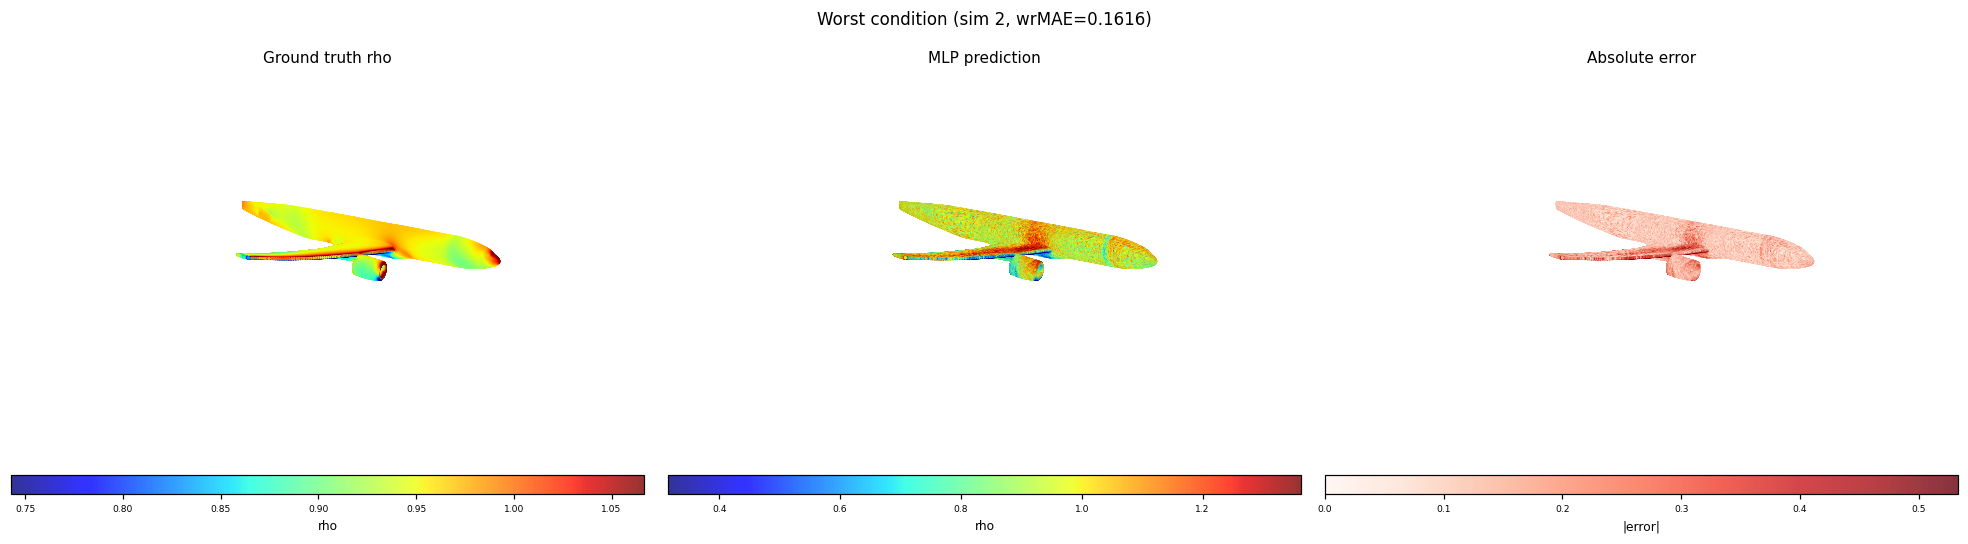

In [5]:
from kit_utils import pca_plots as PP

iworst_wrmae, wrmae_worst, _ = M.compute_wrMAE(y_train, y_cv_mlp, train_weights)
Minf, AoA, Pi = train_conds[iworst_wrmae]
print(f'Worst wrMAE condition: sim {iworst_wrmae}  Minf={Minf:.2f}  AoA={AoA:.1f}  '
      f'Pi={Pi:.0e}  wrMAE={wrmae_worst:.4f}')

sl = slice(iworst_wrmae * M.NWALLP, (iworst_wrmae + 1) * M.NWALLP)
X_sim, y_sim, yhat_sim = X_train[sl], y_train[sl], y_cv_mlp[sl]

PP.plot_condition(X_sim, y_sim, yhat_sim, title_suffix=f' (sim {iworst_wrmae}, wrMAE={wrmae_worst:.4f})',
                   model_name='MLP')

### 4.2 Where does the error come from? PCA error directions

We weight each wall point by `|error|^gamma` and take the (weighted) PCA of its
coordinates: the first axis `u` follows the direction the error is most spread along
(e.g. a shock line), the second `v` cuts across it -- drawn here directly on the
aircraft body.

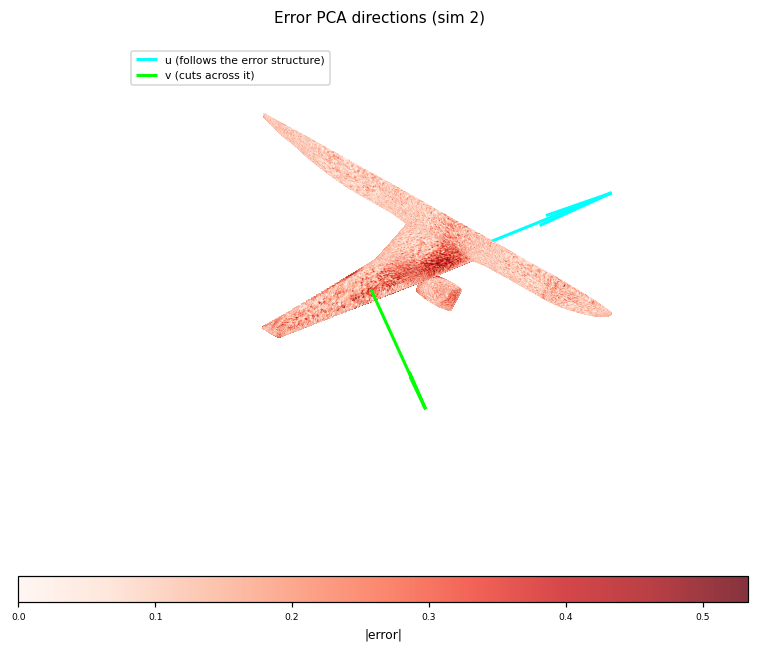

In [6]:
PP.plot_condition_error_pca(X_sim, y_sim, yhat_sim, comp_masks, comp_name='wing',
                             title_suffix=f' (sim {iworst_wrmae})')

### 4.3 Slices across the error structure

Using the `(u, v)` directions from above, we auto-detect the `u` positions where rho
varies the most and plot true-vs-predicted rho along `v` at each one -- i.e. slices
perpendicular to the worst error structure, extrados/intrados separated.

  slices placed at u = ['-1.44', '2.39', '6.22']


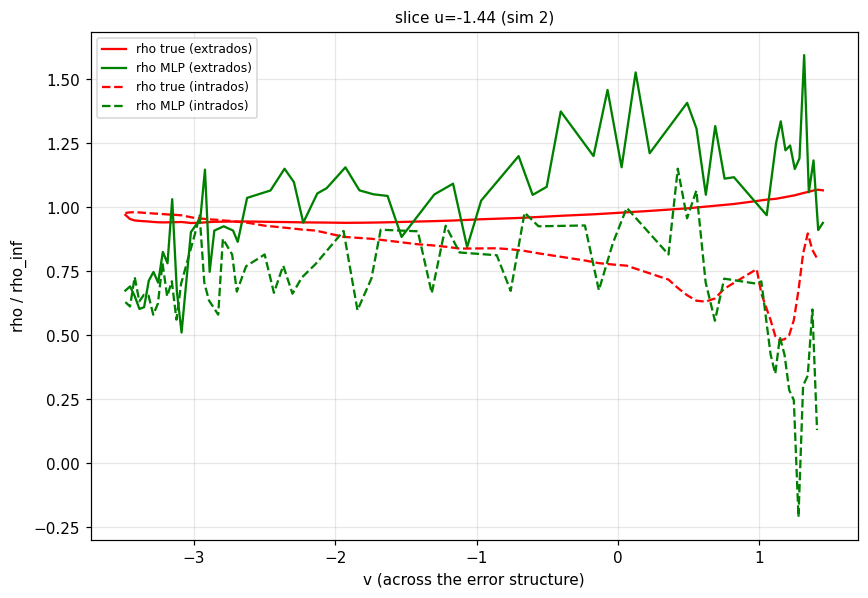

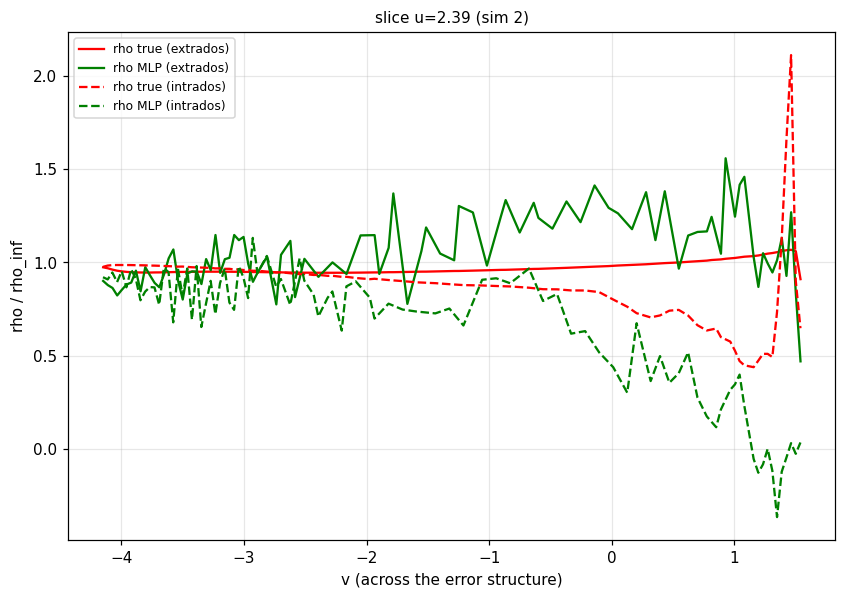

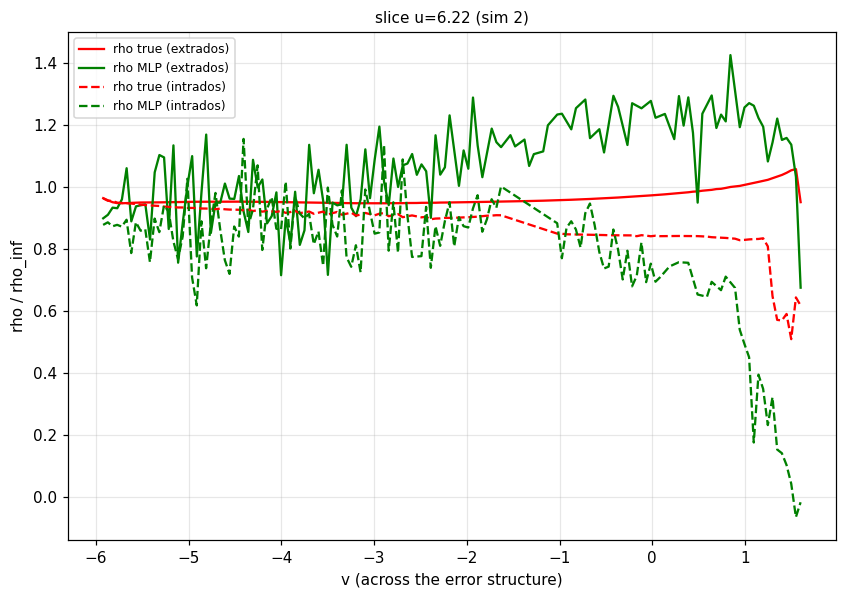

In [7]:
PP.analyse_coupes_auto(X_sim, y_sim, yhat_sim, comp_masks, comp_name='wing',
                        model_name='MLP', n_slices=3, title_suffix=f' (sim {iworst_wrmae})')

---
## 5. Preparing the submission

Your submission is a zip containing `model.py` with a `Model` class implementing
`fit(X, y)` / `predict(X)`. We write out a **self-contained** version of the MLP
baseline below (no `kit_utils` import -- Codabench only sees `model.py`), zip it, and
you're ready to upload.

Two things worth knowing before you tweak this:
- `fit()` is called by the *official* ingestion program on the real training set, so
  it re-trains from scratch at evaluation time -- keep it fast enough to comfortably
  finish inside the competition's execution time limit.
- `Model.fit()` only receives `X, y` -- it has no access to `component_map.json`, so
  it can't apply the official per-component KL weights during training (it falls back
  to uniform point weights). If you want that back, you can bundle a copy of
  `component_labels_unique.npy` / `component_map.json` inside your submission zip and
  load them by relative path from `model.py`.

If you'd rather submit the LightGBM baseline instead, swap in
`kit_utils.lgbm_baseline.Model` -- it already matches the same `fit`/`predict`
contract and doesn't need any of this rewriting (no torch dependency to inline).

In [8]:
import os
os.makedirs('submission', exist_ok=True)

In [9]:
%%writefile submission/model.py
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

COL_MINF, COL_AOA, COL_PI = 6, 7, 8
HIDDEN, DROPOUT = (64,), 0.1
N_EPOCHS, BATCH, LR = 40, 16, 3e-3
VAL_FRAC, PATIENCE, SEED = 0.15, 8, 0


class GlobalMLP(nn.Module):
    """ (Minf, AoA, Pi) -> full rho field of length n_out (= nwallp). """

    def __init__(self, n_out, hidden=HIDDEN, dropout=DROPOUT, mean_field=None):
        super().__init__()
        layers, d = [], 3
        for h in hidden:
            layers += [nn.Linear(d, h), nn.LeakyReLU(0.01)]
            if dropout > 0.0:
                layers += [nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, n_out)]
        self.net = nn.Sequential(*layers)
        mf = torch.zeros(n_out) if mean_field is None else torch.as_tensor(mean_field, dtype=torch.float32)
        self.register_buffer('mean_field', mf)

    def forward(self, c):
        return self.mean_field + self.net(c)


def gaussian_kl_loss(y_pred, y_true, w_pts, sigma_ref):
    """ Closed-form KL(N(bias, spread^2) || N(0, sigma_ref^2)) per row --
    see the starting kit notebook (section 2.2) for the explanation. """
    eps    = y_pred - y_true
    bias   = eps @ w_pts
    var    = ((eps - bias.unsqueeze(1)) ** 2) @ w_pts
    spread = torch.sqrt(var + 1e-12)
    return torch.log(sigma_ref / spread) + (var + bias ** 2) / (2.0 * sigma_ref ** 2) - 0.5


class Model:

    def __init__(self):
        self.model  = None
        self.scaler = StandardScaler()
        self.nwallp = None

    def fit(self, X, y):
        cond0 = X[0, COL_MINF:COL_PI + 1]
        self.nwallp = int(np.argmax(np.any(X[:, COL_MINF:COL_PI + 1] != cond0, axis=1)))
        n_sims = X.shape[0] // self.nwallp
        conds  = X[::self.nwallp, COL_MINF:COL_PI + 1]
        Y      = y.reshape(n_sims, self.nwallp)

        torch.manual_seed(SEED)
        np.random.seed(SEED)
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        conds_sc  = self.scaler.fit_transform(conds)
        sigma_ref = torch.tensor(max(0.01 * float(np.mean(y)), 1e-6), device=device)
        # No component_map.json available here, so weight every point equally
        # (see notebook section 5 for how to change this).
        w_pts = torch.full((self.nwallp,), 1.0 / self.nwallp, device=device)

        n_val = max(1, int(round(VAL_FRAC * n_sims)))
        perm  = np.random.permutation(n_sims)
        val_idx, tr_idx = perm[:n_val], perm[n_val:]

        C  = torch.tensor(conds_sc, dtype=torch.float32, device=device)
        Yt = torch.tensor(Y, dtype=torch.float32, device=device)
        mean_field = Yt[tr_idx].mean(dim=0).cpu().numpy()

        self.model = GlobalMLP(self.nwallp, mean_field=mean_field).to(device)
        opt   = torch.optim.Adam(self.model.parameters(), lr=LR)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS)

        best_val, best_state, bad_epochs = float('inf'), None, 0
        tr_idx_t  = torch.tensor(tr_idx)
        val_idx_t = torch.tensor(val_idx)

        for epoch in range(N_EPOCHS):
            self.model.train()
            perm_t = tr_idx_t[torch.randperm(len(tr_idx_t))]
            for i in range(0, len(perm_t), BATCH):
                idx  = perm_t[i:i + BATCH]
                pred = self.model(C[idx])
                loss = gaussian_kl_loss(pred, Yt[idx], w_pts, sigma_ref).mean()
                opt.zero_grad()
                loss.backward()
                opt.step()
            sched.step()

            self.model.eval()
            with torch.no_grad():
                val_loss = gaussian_kl_loss(
                    self.model(C[val_idx_t]), Yt[val_idx_t], w_pts, sigma_ref).mean().item()
            if val_loss < best_val - 1e-4:
                best_val, bad_epochs = val_loss, 0
                best_state = {k: v.detach().clone() for k, v in self.model.state_dict().items()}
            else:
                bad_epochs += 1
            if bad_epochs >= PATIENCE:
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
        self.model.eval()
        return self

    def predict(self, X):
        device = next(self.model.parameters()).device
        conds  = X[::self.nwallp, COL_MINF:COL_PI + 1]
        with torch.no_grad():
            C = torch.tensor(self.scaler.transform(conds), dtype=torch.float32, device=device)
            y_pred = self.model(C).cpu().numpy().astype(np.float64)
        return y_pred.reshape(-1)


Overwriting submission/model.py


In [10]:
import zipfile

with zipfile.ZipFile('submission.zip', 'w') as zf:
    zf.write('submission/model.py', arcname='model.py')

print('submission.zip created')

submission.zip created
